In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

import sys
sys.path.append('../src') 

# Import the correct class name!
from model import TerrainGenerator
from config import LATENT_DIM, TILE_SIZE

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Testing on: {device}")

# Initialize the architecture using TerrainGenerator
generator = TerrainGenerator(LATENT_DIM).to(device)

# Load the weights 
weights_path = '../models/generator.pth'
state_dict = torch.load(weights_path, map_location=device)

generator.load_state_dict(state_dict)
generator.eval()
print("Weights loaded successfully!")

Testing on: cuda
Weights loaded successfully!


In [10]:
# Generate a batch of 1 random noise vector
# Shape: [Batch_Size, Channels, Height, Width] -> [1, LATENT_DIM, 1, 1]
noise = torch.randn(1, LATENT_DIM, 1, 1, device=device)

# Pass it through the generator (no gradients needed for testing)
with torch.no_grad():
    fake_terrain_tensor = generator(noise)

# Move to CPU, remove batch and channel dimensions, and convert to NumPy
# Shape becomes just [TILE_SIZE, TILE_SIZE]
terrain_map = fake_terrain_tensor.squeeze().cpu().numpy()

print(f"Generated terrain shape: {terrain_map.shape}")
print(f"Elevation Min: {terrain_map.min():.2f}, Max: {terrain_map.max():.2f}")

Generated terrain shape: (3, 256, 256)
Elevation Min: 0.00, Max: 0.98


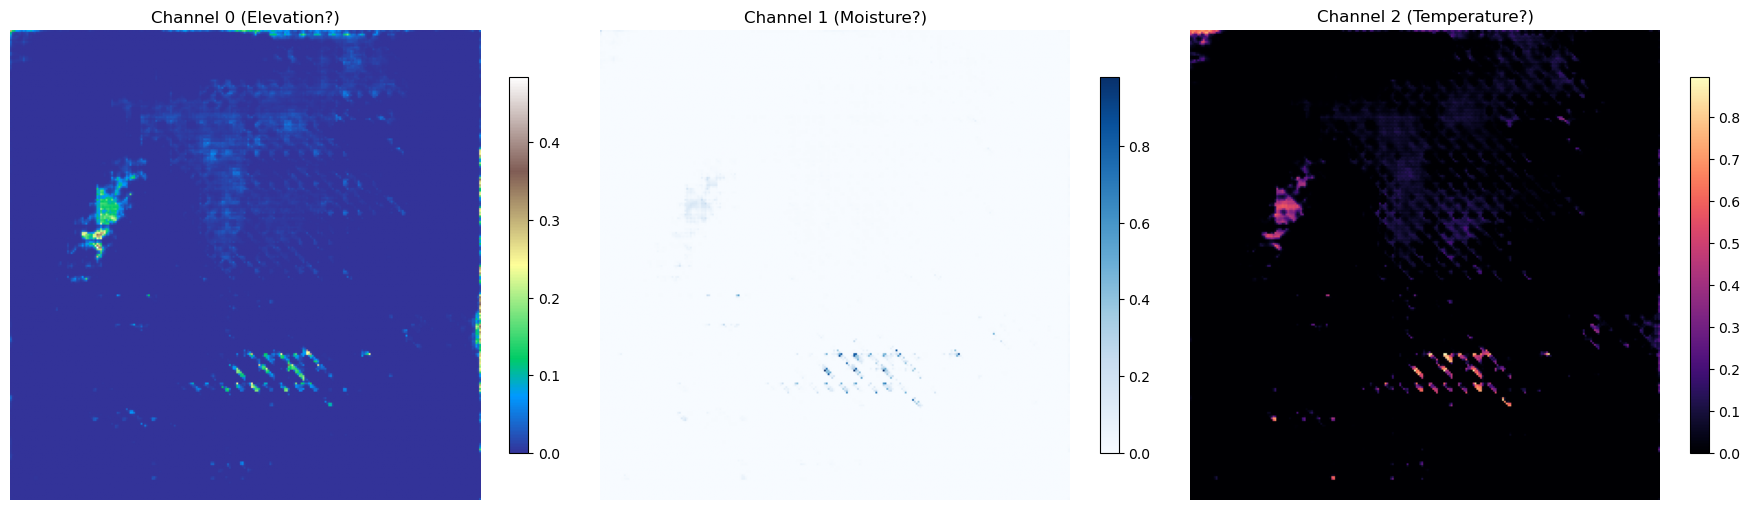

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Channel 0
im0 = axes[0].imshow(terrain_map[0], cmap='terrain')
axes[0].set_title("Channel 0 (Elevation?)")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

# Plot Channel 1
im1 = axes[1].imshow(terrain_map[1], cmap='Blues')
axes[1].set_title("Channel 1 (Moisture?)")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

# Plot Channel 2
im2 = axes[2].imshow(terrain_map[2], cmap='magma')
axes[2].set_title("Channel 2 (Temperature?)")
fig.colorbar(im2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

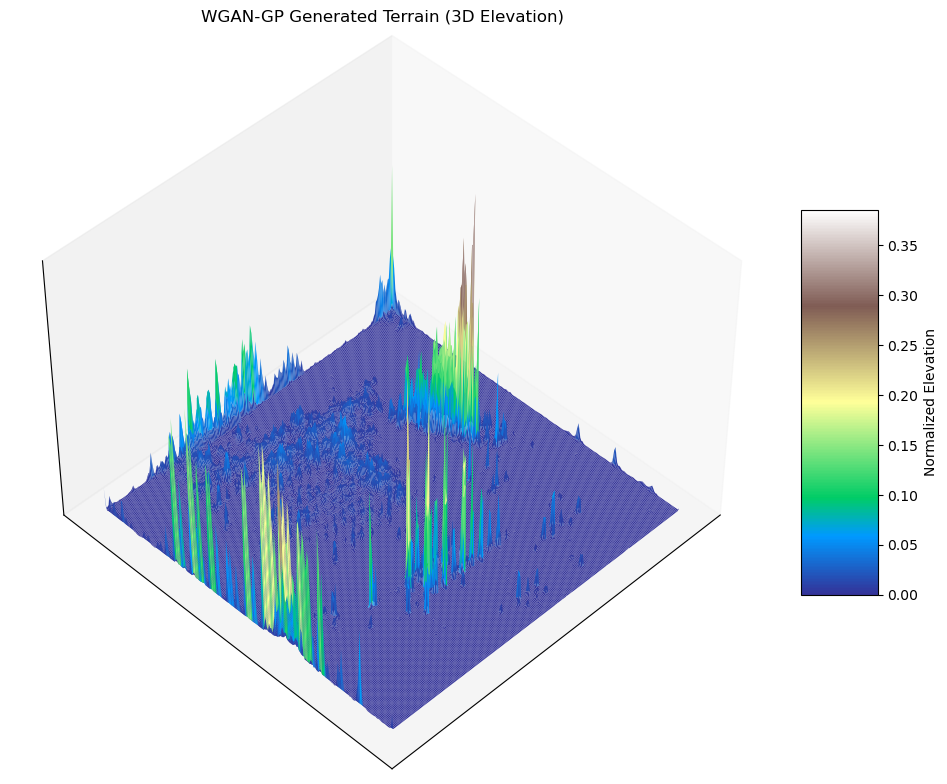

In [12]:
# Isolate just the Elevation channel for the 3D geometry
elevation = terrain_map[0]

# Create X and Y coordinate grids using the 2D elevation shape
x = np.arange(0, elevation.shape[1], 1)
y = np.arange(0, elevation.shape[0], 1)
x, y = np.meshgrid(x, y)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# FIX: Pass the 2D elevation map as the Z argument
surf = ax.plot_surface(x, y, elevation, cmap='terrain', 
                       linewidth=0, antialiased=True, rstride=1, cstride=1)

# Adjust the viewing angle (Elevation, Azimuth)
ax.view_init(elev=45, azim=45)

ax.set_title("WGAN-GP Generated Terrain (3D Elevation)")
fig.colorbar(surf, shrink=0.5, aspect=5, label='Normalized Elevation')

# Remove axis numbers for a cleaner look
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.show()